In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Import sklearn library to Build Tree - Based Model
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split

#Import sklearn library to evaluate model using MAE, MSE & MAPE
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, max_error, r2_score

pd.options.mode.chained_assignment = None # Disable warning from pandas library
# pd.options.mode.chained_assignment = 'warn' # enable warning from pandas library

In [2]:
dataDF = pd.read_csv('SNRE_Data_w_Dummy_for_SPSS.csv')

# Separate Input variables (x) and target variable (y)
x = dataDF.drop(['Unit Price ($ psf)','Floor Level','First Floor','Type of Sale', 'New Sale',
                 'Central Region','Region'], axis=1)

#y = dataDF['Price'] # this is my df of prices, what i want to predict
y = dataDF['Unit Price ($ psf)']

print(x.info())
print(y.info())


#Split the dataset into the training and testing set.
input_train, input_test, target_train, target_test = train_test_split(x, y, test_size=0.2, random_state=42,
                                                                  shuffle = True) # Previously shuffle is True
print('Training Set has {} rows'.format(input_train.shape[0]))
print('Testing Set has {} rows'.format(input_test.shape[0]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9297 entries, 0 to 9296
Data columns (total 17 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Non-First Floor                             9297 non-null   int64  
 1   Resale                                      9297 non-null   int64  
 2   Subsale                                     9297 non-null   int64  
 3   East Region                                 9297 non-null   int64  
 4   North Region                                9297 non-null   int64  
 5   North-East Region                           9297 non-null   int64  
 6   West Region                                 9297 non-null   int64  
 7   Remaining Tenure (Years)                    9297 non-null   int64  
 8   Total Population                            9297 non-null   float64
 9   SORA (%)                                    9297 non-null   float64
 10  Real GDP (in

Random Forest Model 
===========
1. Uses the Default Setting, n_estimators = 100

In [3]:
start_time_1 = time.time()
default_rfModel = RandomForestRegressor(n_estimators = 100, criterion = 'absolute_error', 
                                oob_score = True,random_state = 42) 

default_rfModel.fit(input_train, target_train)

default_rfModel_pred = default_rfModel.predict(input_test)
default_rfModel_score = default_rfModel.score(input_test, target_test)

# Compute Error metrics for RF Model
default_rfpred_mae = mean_absolute_error(target_test,default_rfModel_pred)
default_rfpred_mse = mean_squared_error(target_test,default_rfModel_pred)
default_rfpred_mape = mean_absolute_percentage_error(target_test,default_rfModel_pred)
default_rfpred_max = max_error(target_test,default_rfModel_pred)

fit_time_1 = time.time() - start_time_1

print('Mae: {}'.format(default_rfpred_mae.round(2)))
print('Mse: {}'.format(default_rfpred_mse.round(2)))
print('Mape: {}'.format(default_rfpred_mape.round(2)))
print('Max: {}'.format(default_rfpred_max.round(2)))
print('R2: {}'.format(default_rfModel_score.round(2)))
print('Time: {} sec'.format(fit_time_1))

Mae: 35.51
Mse: 2827.17
Mape: 0.1
Max: 357.69
R2: 0.84
Time: 94.95631313323975 sec


In [4]:
# Find the max and min Tree Depth of all the DT in the default RF Model 
# https://stackoverflow.com/questions/34214087/how-do-you-access-tree-depth-in-pythons-scikit-learn
def getDepthofeachTree(rfModel):
    treeDepthList = []
    for tree in rfModel.estimators_:
        treeDepth = tree.get_depth()
        treeDepthList.append(treeDepth)
    minTreeDepth = min(treeDepthList)
    maxTreeDepth = max(treeDepthList)
    print('In the Random Forest Model with the defaults settings:')    
    print('Max Depth of each Tree in RF: {}'.format(maxTreeDepth))
    print('Min Depth of each Tree in RF: {}'.format(minTreeDepth))
    print('Avg Depth of each Tree in RF: {}'.format(sum(treeDepthList)/len(treeDepthList)))   
    
    return treeDepthList, int(minTreeDepth), int(maxTreeDepth)

In [5]:
listTree,minTreeDepth , maxTreeDepth = getDepthofeachTree(default_rfModel)
print(minTreeDepth + 1)

In the Random Forest Model with the defaults settings:
Max Depth of each Tree in RF: 42
Min Depth of each Tree in RF: 30
Avg Depth of each Tree in RF: 34.9
31


In [6]:
#[print((est.get_depth(), est.tree_.max_depth, est.max_depth)) for est in rfModel.estimators_]

## FRAMEWORK FOR CONDITIONAL COUNT ##

# Define any condition here
def condition(x):
  return x <= minTreeDepth

# Count the number of matching elements
print(sum(condition(x) for x in listTree))
# What's the output?

2


,Input,Rank
0,lagged psf,65.566
1,Remaining Tenure (Years),6.634
2,minDistToMRT,5.665
3,SORA (%),5.267
4,Rental Index % change,4.477
5,Total Multiple-User Factory Space (m2),3.083
6,Non-First Floor,2.415
7,TPI % Change,1.552
8,Total Population,1.056
9,East Region,0.893


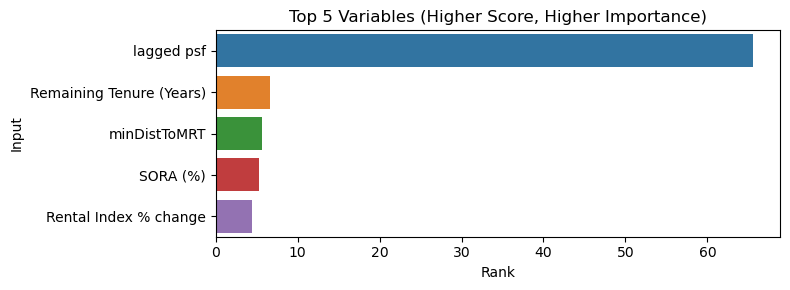

In [7]:
def getInputRank(rfModel):
    rf_inputs_rank = pd.DataFrame({'Input':rfModel.feature_names_in_,
                                   'Rank' :rfModel.feature_importances_.round(5)*100})
    rf_inputs_rank.sort_values(by='Rank', ascending = False, inplace=True)
    rf_inputs_rank.reset_index(drop=True, inplace=True)
    display(rf_inputs_rank)
    plt.figure(figsize=(8, 3))  # Set the figure size
    sns.barplot(x=rf_inputs_rank["Rank"].head(5), y=rf_inputs_rank["Input"].head(5))
    plt.title('Top 5 Variables (Higher Score, Higher Importance)')
    plt.tight_layout()  # Adjust subplot spacing
    plt.show()
    return rf_inputs_rank

InputRankDF = getInputRank(default_rfModel)

In [8]:
print(default_rfModel.oob_score_)

0.8313404198460447


In [9]:
InputRankDF['Input'].head(5).tolist()

['lagged psf',
 'Remaining Tenure (Years)',
 'minDistToMRT',
 'SORA (%)',
 'Rental Index % change']

Hyperparameter Tuning for Full RandomForest Model
======================
1. No. of Decision Tree Estimators (n_estimators)
2. Maximum Depth of each Decision Tree Estimator (max_depth)
3. Uses all inputs instead of a subset

In [10]:
from sklearn.model_selection import GridSearchCV

# Setup the RF Model - randomForest
randomForest = RandomForestRegressor(random_state = 42)

# set the search space - hyperParameters
hyperParameters = {'n_estimators':np.arange(98,101,1),
                   'max_depth':np.arange(14,19,1)}    

# Create the GridSearchCV object
rfGS = GridSearchCV(estimator = randomForest,  #This is the model i trying to optimise
                    param_grid = hyperParameters, # What is the Hyperparameter am I trying to finetune.
                    scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error', 
                               'neg_mean_absolute_percentage_error', 'r2'], # what is the metric I'm going to use.
                    cv = 10,
                    refit = 'neg_mean_absolute_error',
                    verbose = 1)

print(len(hyperParameters['n_estimators']), len(hyperParameters['max_depth']))

3 5


In [11]:
rfGS.fit(input_train, target_train)

Fitting 10 folds for each of 15 candidates, totalling 150 fits


GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': array([14, 15, 16, 17, 18]),
                         'n_estimators': array([ 98,  99, 100])},
             refit='neg_mean_absolute_error',
             scoring=['neg_mean_absolute_error', 'neg_mean_squared_error',
                      'neg_mean_absolute_percentage_error', 'r2'],
             verbose=1)

In [12]:
print(rfGS.best_params_)
print(rfGS.best_score_)
print(rfGS.best_estimator_)

{'max_depth': 15, 'n_estimators': 100}
-34.510872804655776
RandomForestRegressor(max_depth=15, random_state=42)


,param_max_depth,param_n_estimators,params,mean_test_neg_mean_absolute_error
0,14,98,"{'max_depth': 14, 'n_estimators': 98}",34.627629
1,15,98,"{'max_depth': 15, 'n_estimators': 98}",34.518890
2,16,98,"{'max_depth': 16, 'n_estimators': 98}",34.536777
3,17,98,"{'max_depth': 17, 'n_estimators': 98}",34.550763
4,18,98,"{'max_depth': 18, 'n_estimators': 98}",34.606558


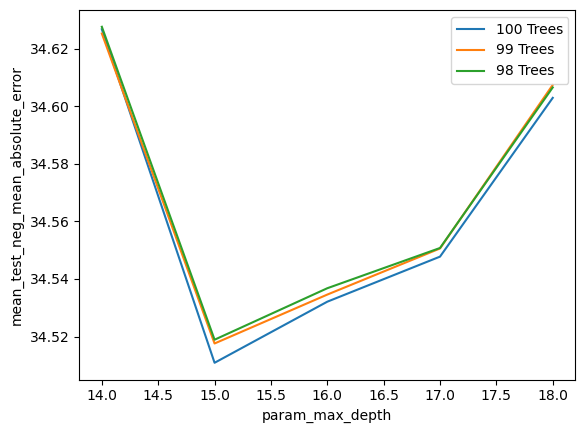

In [13]:
rf_df = pd.DataFrame(rfGS.cv_results_)
rf_df = rf_df[['param_max_depth','param_n_estimators','params','mean_test_neg_mean_absolute_error']]
rf_df['params'] = rf_df['params'].astype('str')
rf_df['mean_test_neg_mean_absolute_error'] = rf_df['mean_test_neg_mean_absolute_error'].abs()
rf_df_100 = rf_df[rf_df['param_n_estimators']==100].reset_index(drop=True)
rf_df_99 = rf_df[rf_df['param_n_estimators']==99].reset_index(drop=True)
rf_df_98 = rf_df[rf_df['param_n_estimators']==98].reset_index(drop=True)
display(rf_df_98)
# rf_df.to_csv('results.csv')
sns.lineplot(data=rf_df_100, x="param_max_depth", y="mean_test_neg_mean_absolute_error", label='100 Trees')
sns.lineplot(data=rf_df_99, x="param_max_depth", y="mean_test_neg_mean_absolute_error", label='99 Trees')
sns.lineplot(data=rf_df_98, x="param_max_depth", y="mean_test_neg_mean_absolute_error", label='98 Trees')
plt.legend()

Full Random Forest Model with Updated Hyperparameter
===========================
1. max_depth = 15    Previously - 28, 16
2. n_estimators = 100

In [14]:
start_time_2 = time.time()

rfModel_tuned = RandomForestRegressor(max_depth = 15, n_estimators = 100, criterion = 'absolute_error', 
                                oob_score = True,random_state = 42) 

rfModel_tuned.fit(input_train, target_train)

rfModel_tuned_pred = rfModel_tuned.predict(input_test)
rfModel_tuned_score = rfModel_tuned.score(input_test, target_test)

# Compute Error metrics for RF Model
rfpred_tuned_mae = mean_absolute_error(target_test,rfModel_tuned_pred)
rfpred_tuned_mse = mean_squared_error(target_test,rfModel_tuned_pred)
rfpred_tuned_mape = mean_absolute_percentage_error(target_test,rfModel_tuned_pred)
rfpred_tuned_max = max_error(target_test,rfModel_tuned_pred)

fit_time_2 = time.time() - start_time_2

print('Mae: {}'.format(rfpred_tuned_mae.round(2)))
print('Mse: {}'.format(rfpred_tuned_mse.round(2)))
print('Mape: {}'.format(rfpred_tuned_mape.round(2)))
print('Max: {}'.format(rfpred_tuned_max.round(2)))
print('R2: {}'.format(rfModel_tuned_score.round(2)))
print('Time: {} sec'.format(fit_time_2))

Mae: 34.98
Mse: 2725.38
Mape: 0.1
Max: 362.47
R2: 0.84
Time: 94.00852656364441 sec


,Input,Rank
0,lagged psf,69.086
1,Remaining Tenure (Years),6.451
2,minDistToMRT,5.281
3,SORA (%),3.949
4,Rental Index % change,3.896
5,Total Multiple-User Factory Space (m2),2.559
6,Non-First Floor,2.457
7,TPI % Change,1.455
8,Total Population,0.964
9,East Region,0.903


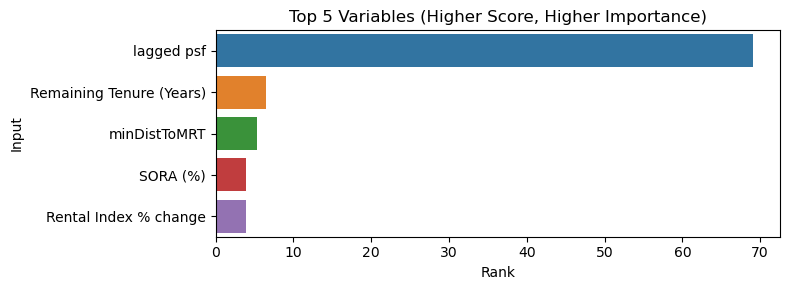

['lagged psf', 'Remaining Tenure (Years)', 'minDistToMRT', 'SORA (%)', 'Rental Index % change']


In [15]:
def getInputRank(rfModel):
    rf_inputs_rank = pd.DataFrame({'Input':rfModel.feature_names_in_,
                                   'Rank' :rfModel.feature_importances_.round(5)*100})
    rf_inputs_rank.sort_values(by='Rank', ascending = False, inplace=True)
    rf_inputs_rank.reset_index(drop=True, inplace=True)
    display(rf_inputs_rank)
    plt.figure(figsize=(8, 3))  # Set the figure size
    sns.barplot(x=rf_inputs_rank["Rank"].head(5), y=rf_inputs_rank["Input"].head(5))
    plt.title('Top 5 Variables (Higher Score, Higher Importance)')
    plt.tight_layout()  # Adjust subplot spacing
    plt.show()
    return rf_inputs_rank


InputRankDF = getInputRank(rfModel_tuned)
top5Input = InputRankDF['Input'].head(5).tolist()
print(top5Input)

Setup Up the Parsimoney RF Model with the following variables
=============
1. lagged psf
2. Remaining Tenure (Years)
3. minDistToMRT
4. SORA (%)
5. Rental Index % change

In [16]:
# Only retain the top 5 variables in the training and testing set. 

# input_train_new = input_train[['lagged psf','Remaining Tenure (Years)', 'SORA (%)', 
#                                'Rental Index % change','Total Multiple-User Factory Space (m2)']]
# input_test_new = input_test[['lagged psf','Remaining Tenure (Years)', 'SORA (%)', 
#                                'Rental Index % change','Total Multiple-User Factory Space (m2)']]

# input_train_new = input_train[InputRankDF['Input'].head(5).tolist()]
# input_test_new = input_test[InputRankDF['Input'].head(5).tolist()]

five_input_train = input_train[top5Input]
five_input_test = input_test[top5Input]

print(five_input_train .info())
print(five_input_test.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7437 entries, 5125 to 7270
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lagged psf                7437 non-null   float64
 1   Remaining Tenure (Years)  7437 non-null   int64  
 2   minDistToMRT              7437 non-null   float64
 3   SORA (%)                  7437 non-null   float64
 4   Rental Index % change     7437 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 348.6 KB
None
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1860 entries, 5151 to 7488
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lagged psf                1860 non-null   float64
 1   Remaining Tenure (Years)  1860 non-null   int64  
 2   minDistToMRT              1860 non-null   float64
 3   SORA (%)                  1860 non-null   float64
 4   Renta

In [17]:
start_time_3 = time.time()

parsi_rfModel = RandomForestRegressor(n_estimators = 100, criterion = 'absolute_error', 
                                    oob_score = True,random_state = 42) 
parsi_rfModel.fit(five_input_train, target_train)

parsi_rfModel_pred = parsi_rfModel.predict(five_input_test)
parsi_rfModel_score = parsi_rfModel.score(five_input_test, target_test)

# Compute Error metrics for RF Model
parsi_rfModel_mae = mean_absolute_error(target_test,parsi_rfModel_pred)
parsi_rfModel_mse = mean_squared_error(target_test,parsi_rfModel_pred)
parsi_rfModel_mape = mean_absolute_percentage_error(target_test,parsi_rfModel_pred)
parsi_rfModel_max = max_error(target_test,parsi_rfModel_pred)

fit_time_3 = time.time() - start_time_3

print('Mae: {}'.format(parsi_rfModel_mae))
print('Mse: {}'.format(parsi_rfModel_mse))
print('Mape: {}'.format(parsi_rfModel_mape))
print('Max: {}'.format(parsi_rfModel_max))
print('R2: {}'.format(parsi_rfModel_score))
print('Time: {} sec'.format(fit_time_3))

Mae: 38.732132500000006
Mse: 3315.516790248126
Mape: 0.11157445938000243
Max: 354.1372499999998
R2: 0.8109891412314947
Time: 48.31960463523865 sec


In [18]:
getDepthofeachTree(parsi_rfModel)

In the Random Forest Model with the defaults settings:
Max Depth of each Tree in RF: 43
Min Depth of each Tree in RF: 29
Avg Depth of each Tree in RF: 34.01


([43,
  33,
  31,
  34,
  32,
  33,
  32,
  40,
  30,
  31,
  29,
  30,
  37,
  37,
  30,
  34,
  35,
  33,
  31,
  32,
  33,
  30,
  43,
  34,
  34,
  37,
  34,
  38,
  35,
  34,
  32,
  32,
  40,
  33,
  32,
  35,
  35,
  33,
  42,
  37,
  32,
  35,
  35,
  35,
  32,
  39,
  34,
  32,
  32,
  37,
  32,
  36,
  34,
  34,
  38,
  32,
  31,
  37,
  35,
  32,
  34,
  34,
  37,
  32,
  35,
  38,
  30,
  33,
  34,
  31,
  33,
  35,
  34,
  36,
  32,
  34,
  33,
  32,
  31,
  35,
  37,
  32,
  33,
  34,
  32,
  39,
  34,
  31,
  32,
  34,
  33,
  30,
  34,
  32,
  32,
  34,
  34,
  33,
  42,
  32],
 29,
 43)

Hyperparameter Tuning of the Parsimony RF Model
===============

In [19]:
from sklearn.model_selection import GridSearchCV

# Setup the RF Model - randomForest
parsi_randomForest = RandomForestRegressor(random_state = 42)

# set the search space - hyperParameters
hyperParameters = {'n_estimators':np.arange(98,101,1),
                   'max_depth':np.arange(12,17,1)}    

# Create the GridSearchCV object
prfGS = GridSearchCV(estimator = parsi_randomForest,  #This is the model i trying to optimise
                    param_grid = hyperParameters, # What is the Hyperparameter am I trying to finetune.
                    scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error', 
                               'neg_mean_absolute_percentage_error', 'r2'], # what is the metric I'm going to use.
                    cv = 10,
                    refit = 'neg_mean_absolute_error',
                    verbose = 1)

print(len(hyperParameters['n_estimators']), len(hyperParameters['max_depth']))

3 5


In [20]:
prfGS.fit(five_input_train, target_train)

Fitting 10 folds for each of 15 candidates, totalling 150 fits


GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': array([12, 13, 14, 15, 16]),
                         'n_estimators': array([ 98,  99, 100])},
             refit='neg_mean_absolute_error',
             scoring=['neg_mean_absolute_error', 'neg_mean_squared_error',
                      'neg_mean_absolute_percentage_error', 'r2'],
             verbose=1)

In [21]:
print(prfGS.best_params_)
print(prfGS.best_score_)
print(prfGS.best_estimator_)

{'max_depth': 14, 'n_estimators': 100}
-38.50563842854031
RandomForestRegressor(max_depth=14, random_state=42)


,param_max_depth,param_n_estimators,params,mean_test_neg_mean_absolute_error
0,12,98,"{'max_depth': 12, 'n_estimators': 98}",38.578194
1,12,99,"{'max_depth': 12, 'n_estimators': 99}",38.575104
2,12,100,"{'max_depth': 12, 'n_estimators': 100}",38.572885
3,13,98,"{'max_depth': 13, 'n_estimators': 98}",38.519282
4,13,99,"{'max_depth': 13, 'n_estimators': 99}",38.518462
5,13,100,"{'max_depth': 13, 'n_estimators': 100}",38.514390
6,14,98,"{'max_depth': 14, 'n_estimators': 98}",38.515872
7,14,99,"{'max_depth': 14, 'n_estimators': 99}",38.512945
8,14,100,"{'max_depth': 14, 'n_estimators': 100}",38.505638
9,15,98,"{'max_depth': 15, 'n_estimators': 98}",38.525362


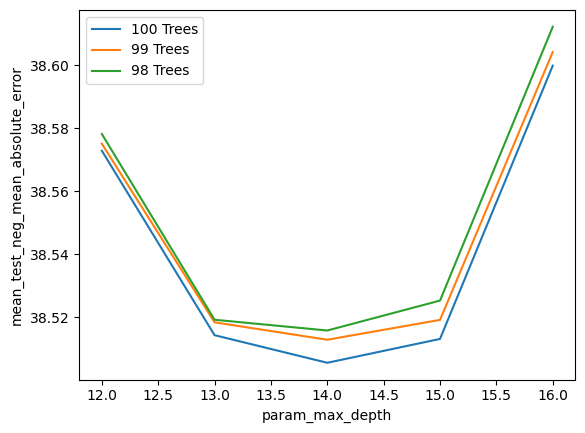

In [22]:
prf_df = pd.DataFrame(prfGS.cv_results_)
prf_df = prf_df[['param_max_depth','param_n_estimators','params','mean_test_neg_mean_absolute_error']]
prf_df['params'] = prf_df['params'].astype('str')
prf_df['mean_test_neg_mean_absolute_error'] = prf_df['mean_test_neg_mean_absolute_error'].abs()
prf_df_100 = prf_df[prf_df['param_n_estimators']==100].reset_index(drop=True)
prf_df_99 = prf_df[prf_df['param_n_estimators']==99].reset_index(drop=True)
prf_df_98 = prf_df[prf_df['param_n_estimators']==98].reset_index(drop=True)
display(prf_df)
# rf_df.to_csv('results.csv')
sns.lineplot(data=prf_df_100, x="param_max_depth", y="mean_test_neg_mean_absolute_error", label='100 Trees')
sns.lineplot(data=prf_df_99, x="param_max_depth", y="mean_test_neg_mean_absolute_error", label='99 Trees')
sns.lineplot(data=prf_df_98, x="param_max_depth", y="mean_test_neg_mean_absolute_error", label='98 Trees')
plt.legend()

Parsimoney Random Forest Model with Updated Hyperparameter
===========================
1. max_depth = 14, previously = 27
2. n_estimators = 100 

In [23]:
start_time_4 = time.time()

parsi_rfModel_tuned = RandomForestRegressor(max_depth = 14, n_estimators = 100, criterion = 'absolute_error', 
                                oob_score = True,random_state = 42) 

parsi_rfModel_tuned.fit(five_input_train, target_train)

parsi_rfModel_tuned_pred = parsi_rfModel_tuned.predict(five_input_test)
parsi_rfModel_tuned_score = parsi_rfModel_tuned.score(five_input_test, target_test)

# Compute Error metrics for RF Model
parsi_rfpred_tuned_mae = mean_absolute_error(target_test,parsi_rfModel_tuned_pred)
parsi_rfpred_tuned_mse = mean_squared_error(target_test,parsi_rfModel_tuned_pred)
parsi_rfpred_tuned_mape = mean_absolute_percentage_error(target_test,parsi_rfModel_tuned_pred)
parsi_rfpred_tuned_max = max_error(target_test,parsi_rfModel_tuned_pred)

fit_time_4 = time.time() - start_time_4

print('Mae: {}'.format(parsi_rfpred_tuned_mae))
print('Mse: {}'.format(parsi_rfpred_tuned_mse))
print('Mape: {}'.format(parsi_rfpred_tuned_mape))
print('Max: {}'.format(parsi_rfpred_tuned_max))
print('R2: {}'.format(parsi_rfModel_tuned_score))
print('Time: {} sec'.format(fit_time_4))

Mae: 38.14198564516129
Mse: 3214.424847693017
Mape: 0.1105036452040909
Max: 357.5445999999999
R2: 0.8167521869603289
Time: 49.54234576225281 sec


In [24]:
scoreDF = pd.DataFrame(data={'RF Model':['Default RF','Default RF(Tuned)','Parsimonious RF', 'Parsi RF(Tuned)'],
                             'MAE ($)':[default_rfpred_mae,rfpred_tuned_mae,parsi_rfModel_mae,parsi_rfpred_tuned_mae],
                             'MSE ($)':[default_rfpred_mse,rfpred_tuned_mse,parsi_rfModel_mse,parsi_rfpred_tuned_mse],
                             'MAPE (%)':[default_rfpred_mape,rfpred_tuned_mape,parsi_rfModel_mape,parsi_rfpred_tuned_mape],
                             'R2':[default_rfModel_score,rfModel_tuned_score,parsi_rfModel_score,parsi_rfModel_tuned_score],
                             'max_depth':[np.nan,rfGS.best_params_['max_depth'],np.nan,prfGS.best_params_['max_depth']],
                             'n_estimators':[100,rfGS.best_params_['n_estimators'],100,prfGS.best_params_['n_estimators']],
                             'Compute Time (Sec)':[fit_time_1, fit_time_2, fit_time_3, fit_time_4]})

pd.options.display.float_format = '{:.2f}'.format
display(scoreDF)


,RF Model,MAE ($),MSE ($),MAPE (%),R2,max_depth,n_estimators,Compute Time (Sec)
0,Default RF,35.51,2827.17,0.10,0.84,NaN,100,94.96
1,Default RF(Tuned),34.98,2725.38,0.10,0.84,15.00,100,94.01
2,Parsimonious RF,38.73,3315.52,0.11,0.81,NaN,100,48.32
3,Parsi RF(Tuned),38.14,3214.42,0.11,0.82,14.00,100,49.54
